# Report 2: Exploration of energy usage and devices

This report aims to use the provided data on electricity usage per month .

I don't think it makes sense to look at the same variable as the report elena & Miro are doing.

------------------------------

This report aims to use the provided data on electricity and gas usage, as well as the data on the devices that were installed in the house to provide an overview of the consumption of gas and electricity throughout the day, as well as to analyse how device usage differs between day and night.


We can start by importing the home messages file and creating the "myhome" database. Then we can insert the files into the database and return the data from the database as a pandas dataframe.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from home_messages_db import *
import datetime
db = HomeMessagesDB("sqlite:///myhome.db")
db.create_db()

First lets insert the files into the database

In [13]:
files = check_filepaths("P1e-*.csv.gz","P1e")
for file in files:
    db.insert_table_P1e(file)

In [2]:
files = check_filepaths("smartthings*.tsv.gz","smartthings")

for file in files:
    db.insert_table_smartthings(file)

In [ ]:
files = check_filepaths("P1g-*.csv.gz","P1g")
for file in files:
    db.insert_table_P1g(file)

And now fetch them and insert them into a pandas dataframe

In [3]:
smart_things = db.return_whole_table("smartthings")


In [4]:

smart_things.head(20)

,id,name,epoch,capability,attribute,unit,value_int,value_str
0,1,Bathroom (flower),1665346388,switch,switch,None,NaN,off
1,2,Bathroom (flower),1665346388,switch,switch,None,NaN,off
2,3,Bathroom (flower),1665346402,switch,switch,None,NaN,on
3,4,Bathroom (flower),1665347032,switch,switch,None,NaN,off
4,5,Bathroom (flower),1665347091,switch,switch,None,NaN,on
5,6,Bathroom (sink),1665347673,switch,switch,None,NaN,on
6,7,Door (main),1665348949,voltageMeasurement,voltage,V,3.035,None
7,8,Bathroom (sink),1665349178,switch,switch,None,NaN,off
8,9,Bathroom (flower),1665349812,switch,switch,None,NaN,off
9,10,Bathroom (bathtube),1665350596,switch,switch,None,NaN,on


In [10]:
signal = smart_things[smart_things.attribute == "rssi"]
signal


,id,name,epoch,capability,attribute,unit,value_int,value_str
14,15,Door (main),1665351958,signalStrength,rssi,dBm,-54.0,None
25,26,Door (main),1665357976,signalStrength,rssi,dBm,-53.0,None
28,29,Door (main),1665370011,signalStrength,rssi,dBm,-52.0,None
42,43,Door (main),1665388068,signalStrength,rssi,dBm,-57.0,None
44,45,Door (main),1665406122,signalStrength,rssi,dBm,-55.0,None
...,...,...,...,...,...,...,...,...
2397434,2397435,Door (main),1744461315,signalStrength,rssi,dBm,-45.0,None
2397483,2397484,Door (garden),1744463942,signalStrength,rssi,dBm,-72.0,None
2397548,2397549,Door (main),1744466627,signalStrength,rssi,dBm,-42.0,None
2397634,2397635,Door (garden),1744469986,signalStrength,rssi,dBm,-70.0,None


Average over each 60 seconds to have measurements per minute

<Axes: xlabel='epoch', ylabel='value_int'>

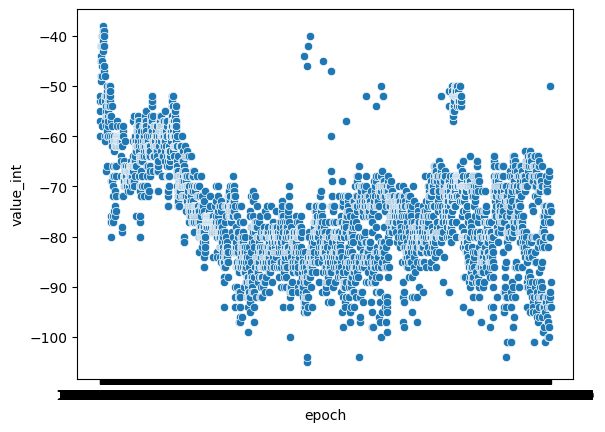

In [12]:
#plt.scatter(signal.epoch,signal.value_int)
sns.scatterplot(signal[1:5000], x = "epoch", y = "value_int")

### Question 1: Does average electricity use change throughout the day?

The First kind of analysis is about the energy usage throughout the day, which means we first need to convert the epochs (so unix time) into datetime and extract the times seperately from the whole date.

In [4]:
Energy_usage["date"] = pd.to_datetime(Energy_usage.loc[:,"epoch"]*10**9).dt.date
Energy_usage["time"] = pd.to_datetime(Energy_usage.loc[:,"epoch"]*10**9).dt.strftime("%H:%M")
Energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2,date,time
0,1647612900,6506.377,5313.255,0.0,0.0,2022-03-18,14:15
1,1647613800,6506.377,5313.516,0.0,0.0,2022-03-18,14:30
2,1647614700,6506.377,5314.241,0.0,0.0,2022-03-18,14:45
3,1647615600,6506.377,5314.800,0.0,0.0,2022-03-18,15:00
4,1647616500,6506.377,5314.933,0.0,0.0,2022-03-18,15:15


Since the energy usage columns indicate the overall energy usage for low and high cost hours we need to create a new column that checks the usage at each timepoint to the previous timepoint for both columns and then takes the sum of those two values as the consumption for that period.

In [5]:
Energy_usage["Usage"] = Energy_usage.loc[:,"Electricity_imported_T1"].diff() + Energy_usage.loc[:,"Electricity_imported_T2"].diff()
Energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2,date,time,Usage
0,1647612900,6506.377,5313.255,0.0,0.0,2022-03-18,14:15,NaN
1,1647613800,6506.377,5313.516,0.0,0.0,2022-03-18,14:30,0.261
2,1647614700,6506.377,5314.241,0.0,0.0,2022-03-18,14:45,0.725
3,1647615600,6506.377,5314.800,0.0,0.0,2022-03-18,15:00,0.559
4,1647616500,6506.377,5314.933,0.0,0.0,2022-03-18,15:15,0.133


Now we can use a lineplot to see how energy consumption varies roughly throughout the day. The red lines mark a shift from high-cost to low-cost hours / vice versa

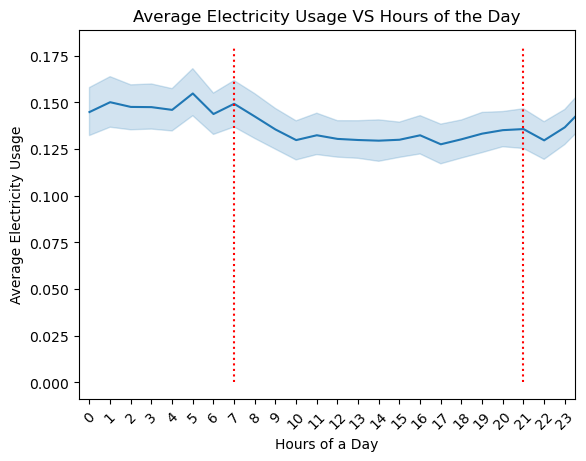

In [8]:
ax = sns.lineplot(Energy_usage, x = "time", y = "Usage", estimator= "mean")
plt.xticks(np.arange(0,24, step = 1), rotation = 45, labels = range(0,24,1))
plt.xlim(-0.5, 23.5)
plt.vlines(x = [7,21], ymin = 0, ymax= 0.18, linestyles= "dotted", color = "red")
ax.set(xlabel = "Hours of a Day", ylabel = "Average Electricity Usage", title = "Average Electricity Usage VS Hours of the Day")
plt.show()

Looking at the plot, there is not a huge difference between the different hours of the day. It does look like more energy is used during the low-cost hours than the high-cost ones, which intuitively does make sense, as this saves money.

### Question 2: Is it possible to identify intervals of time when nobody is home? 


There are multiple ways of approaching this question. First of all, we might hypothesise that during intervals where nobody is home, electricity consumption might be significantly lower than when people are at home. Secondly, gas usage might also be significantly lower when nobody is home -- especially during the coldest days of winter. Third, since smartthings contains data from motion-activated sensors and other devices which need to be used actively in order to be active, if there are large intervals of time when these devices are not used, we can assume that nobody was home to use them. 

#### 2.a: Can we see intervals of time when electricity consumption dips when looking at single dates?

In order to investigate this question, we can take a look at data from a random selection of days throughout the period for which we have data. As such, we draw a random sample of 20 days. Since for the questions pertaining to gas we will need to investigate days in colder months, we restrict the sampling to  the months of November - March.

In [ ]:
max(Energy_usage["date"])

cold_months_24 = Energy_usage.any[Energy_usage["date"] >= datetime.date(2024,10,1) or Energy_usage["date"] <= datetime.date(2024,3,1)]

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().